# Фінальний проєкт. Частина 2: ембеддинги фото і описів

PetFinder: передбачити швидкість адопції (1..4) за фото і текстом оголошення.

Усі фото і описи переводжу у вектори заморожених енкодерів, далі моделі вчаться вже на векторах.
Фото: CLIP ViT-L/14 і SigLIP2 so400m. Текст: текстова вежа CLIP і bge-base.
Результат лежить у `Results/embeddings`, ноутбуки 03 і 04 його тільки читають. Готові файли ноутбук не перераховує.
Найдовший крок, SigLIP2 по 38 тисячах фото, зайняв 33.5 хв на Apple M4 Pro, CLIP близько 20 хв, текст пару хвилин.
На GPU в Colab це в кілька разів швидше.

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoProcessor, AutoTokenizer, logging as hf_logging
from tqdm.auto import tqdm

hf_logging.set_verbosity_error()

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
dtype = torch.float16 if device.type != "cpu" else torch.float32
print(device, dtype)

DATA_DIR = Path("Data")
if not (DATA_DIR / "train.csv").exists():
    import kagglehub
    DATA_DIR = Path(kagglehub.competition_download("deep-learning-for-computer-vision-and-nlp-2026-10"))
CSV_DIR = next(DATA_DIR.rglob("train.csv")).parent
IMG_DIRS = {split: next(p for p in DATA_DIR.rglob(split) if p.is_dir() and any(p.glob("*.jpg"))) for split in ("train", "test")}

EMB_DIR = Path("Results/embeddings")
FIG_DIR = Path("Results/figures")
EMB_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

mps torch.float16


## Індекс фото

Файл фото називається `<PetID>-<номер>.jpg`. У test.csv чотири PetID мають 8 символів замість 9: десь по дорозі
загубився нуль на початку, а в назвах файлів він є. Для пошуку фото доповнюю id нулем зліва, у сабмішен піде PetID
як у test.csv. Ще 8 id у папці test не мають рядка в csv, їх пропускаю.

In [2]:
train = pd.read_csv(CSV_DIR / "train.csv", dtype={"PetID": str})
test = pd.read_csv(CSV_DIR / "test.csv", dtype={"PetID": str})
pets = pd.concat([train.assign(split="train"), test.assign(split="test")], ignore_index=True)
pets["Description"] = pets.Description.fillna("")
pets["img_id"] = pets.PetID.str.zfill(9)

rows = []
for split, d in IMG_DIRS.items():
    for p in sorted(d.glob("*.jpg")):
        img_id, no = p.stem.rsplit("-", 1)
        rows.append((img_id, int(no), str(p)))
photos = pd.DataFrame(rows, columns=["img_id", "photo_no", "path"])
photos = photos.merge(pets[["img_id", "PetID", "split"]], on="img_id")   # inner join: фото без рядка в csv відпадають
photos = photos.sort_values(["split", "img_id", "photo_no"]).reset_index(drop=True)

pets["n_img"] = pets.PetID.map(photos.groupby("PetID").size()).fillna(0).astype(int)
print(photos.split.value_counts().to_dict())
print("тварин:", len(pets), " без фото:", (pets.n_img == 0).sum())
print("PetID з 8 символів:", pets.PetID[pets.PetID.str.len() == 8].tolist())

pets.to_csv(EMB_DIR / "pets.csv", index=False)
photos.to_csv(EMB_DIR / "photos.csv", index=False)

{'train': 28472, 'test': 9377}
тварин: 8322  без фото: 0
PetID з 8 символів: ['95314294', '35992662', '63521459', '81301773']


## Енкодери зображень

Дві контрастивні моделі: `openai/clip-vit-large-patch14` (768 чисел на фото) і `google/siglip2-so400m-patch14-224`
(1152). Їх учили на сотнях мільйонів пар фото-текст, тому простір ознак уже розрізняє вид, породу, вік, стан
тварини і якість знімка. Ваги не чіпаю, тільки прямий прохід у fp16. Кожне фото кодую окремо, агрегація по тварині далі.

In [3]:
class PhotoDataset(Dataset):
    def __init__(self, paths, processor):
        self.paths = paths
        self.processor = processor

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.processor(images=img, return_tensors="pt")["pixel_values"][0]


BATCH_SIZE = 64
NUM_WORKERS = 4 if device.type == "cuda" else 0   # на macOS воркери DataLoader з ноутбука не стартують


def free_memory():
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()


@torch.no_grad()
def encode_images(model_name, paths):
    processor = AutoProcessor.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name, dtype=dtype).to(device).eval()
    loader = DataLoader(PhotoDataset(paths, processor), batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
    out = []
    for px in tqdm(loader, desc=model_name.split("/")[-1], mininterval=30):
        feats = model.get_image_features(pixel_values=px.to(device, dtype))
        out.append(feats.pooler_output.float().cpu())   # transformers 5: проєкція лежить у pooler_output
    del model
    free_memory()
    return torch.cat(out).numpy().astype(np.float16)

In [4]:
IMAGE_ENCODERS = {"clip": "openai/clip-vit-large-patch14", "siglip2": "google/siglip2-so400m-patch14-224"}

for key, name in IMAGE_ENCODERS.items():
    f = EMB_DIR / f"photo_{key}.npy"
    if f.exists():
        cached = np.load(f, mmap_mode="r")
        assert cached.shape[0] == len(photos), "кеш не збігається з індексом фото, видали файл і перерахуй"
        print(f.name, "вже є", cached.shape)
        continue
    t0 = time.time()
    emb = encode_images(name, photos.path.tolist())
    np.save(f, emb)
    print(f.name, emb.shape, f"{(time.time() - t0) / 60:.1f} хв")

photo_clip.npy вже є (37849, 768)
photo_siglip2.npy вже є (37849, 1152)


## Енкодери тексту

Текстова вежа CLIP дає вектор у тому ж просторі, що й фото, але бачить лише перші 77 токенів.
Другий енкодер, `BAAI/bge-base-en-v1.5`, учили саме на подібність речень, він читає до 512 токенів, цього вистачає
майже на всі описи. Беру вектор токена [CLS], як радять автори моделі. Порожній опис кодую як є, це теж інформація.
Текст іде в токенізатори без чистки: регістр і пунктуацію вони обробляють самі, посилань та ієрогліфів у даних
менше 2 %, а чистка лише прибрала б інформацію. Обидві моделі англомовні, малайські вставки (близько 6 % описів)
вони бачать як незнайомі слова, це свідома втрата заради простоти.

In [5]:
@torch.no_grad()
def encode_texts(model_name, texts, max_length, pooling):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name, dtype=dtype).to(device).eval()
    out = []
    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc=model_name.split("/")[-1], mininterval=30):
        batch = tokenizer(texts[i:i + BATCH_SIZE], padding=True, truncation=True, max_length=max_length,
                          return_tensors="pt").to(device)
        if pooling == "clip":
            feats = model.get_text_features(**batch).pooler_output
        else:
            feats = model(**batch).last_hidden_state[:, 0]
        out.append(feats.float().cpu())
    del model
    free_memory()
    return torch.cat(out).numpy().astype(np.float16)


TEXT_ENCODERS = {"clip": ("openai/clip-vit-large-patch14", 77, "clip"), "bge": ("BAAI/bge-base-en-v1.5", 512, "cls")}
texts = pets.Description.tolist()

for key, (name, max_len, pooling) in TEXT_ENCODERS.items():
    f = EMB_DIR / f"text_{key}.npy"
    if f.exists():
        cached = np.load(f, mmap_mode="r")
        assert cached.shape[0] == len(pets), "кеш не збігається з таблицею тварин, видали файл і перерахуй"
        print(f.name, "вже є", cached.shape)
        continue
    emb = encode_texts(name, texts, max_len, pooling)
    np.save(f, emb)
    print(f.name, emb.shape)

text_clip.npy вже є (8322, 768)
text_bge.npy вже є (8322, 768)


## Агрегація по тварині

Вектор кожного фото нормалізую до одиничної довжини, усереднюю по тварині і середнє знову нормалізую. Так тварина
з 20 фото і тварина з одним живуть в одному масштабі, а косинус між тваринами має сенс.
Окремо лишаю вектор першого фото: саме його бачить відвідувач сайту у списку оголошень.

In [6]:
def pool_by_pet(emb):
    e = F.normalize(torch.from_numpy(emb.astype(np.float32)), dim=-1).numpy()
    pos = {pid: i for i, pid in enumerate(pets.PetID)}
    mean = np.zeros((len(pets), e.shape[1]), np.float32)
    first = np.zeros_like(mean)
    for pid, idx in photos.groupby("PetID", sort=False).indices.items():
        v = e[idx].mean(0)
        mean[pos[pid]] = v / np.linalg.norm(v)
        first[pos[pid]] = e[idx[0]]          # photos відсортовано за photo_no, idx[0] це фото номер 1
    return mean.astype(np.float16), first.astype(np.float16)


for key in IMAGE_ENCODERS:
    mean, first = pool_by_pet(np.load(EMB_DIR / f"photo_{key}.npy"))
    np.save(EMB_DIR / f"pet_{key}_mean.npy", mean)
    np.save(EMB_DIR / f"pet_{key}_first.npy", first)
    print(key, mean.shape, "нульових рядків:", int((np.abs(mean).sum(1) == 0).sum()))

for f in sorted(EMB_DIR.iterdir()):
    print(f"{f.name:28s} {f.stat().st_size / 2**20:7.1f} MB")

clip (8322, 768) нульових рядків: 0


siglip2 (8322, 1152) нульових рядків: 0
pet_clip_first.npy              12.2 MB
pet_clip_mean.npy               12.2 MB
pet_siglip2_first.npy           18.3 MB
pet_siglip2_mean.npy            18.3 MB
pets.csv                         3.2 MB
photo_clip.npy                  55.4 MB
photo_siglip2.npy               83.2 MB
photos.csv                       2.5 MB
text_bge.npy                    12.2 MB
text_clip.npy                   12.2 MB


## Перевірка, що вектори осмислені

Спочатку що саме процесори роблять з фото і яку частку описів обрізають токенізатори. CLIP зменшує коротшу
сторону до 224 і бере центральний квадрат, SigLIP2 стискає все фото в 224x224 без кропу, нормалізація у кожного
своя. Для фото 4:3 з EDA це означає, що CLIP втрачає краї кадру, а SigLIP2 трохи спотворює пропорції, обидва
енкодери так і навчалися. Текстовий CLIP обрізає близько 40 % описів на 77 токенах, bge майже нічого.
Далі тести: фото однієї тварини мають бути ближчими одне до одного, ніж випадкові, однакові описи мають давати
однакові вектори (це перевіряє, що рядки не переплутані), zero-shot запит "кіт чи собака" має давати
правдоподібний поділ, а найближчі сусіди тестової тварини мають виглядати схоже.

In [7]:
def compact(size):
    d = size if isinstance(size, dict) else vars(size)
    return {k: v for k, v in d.items() if v is not None}


for key, name in IMAGE_ENCODERS.items():
    ip = AutoProcessor.from_pretrained(name).image_processor
    crop = compact(ip.crop_size) if getattr(ip, "do_center_crop", False) else "без кропу"
    print(f"{key:8s} resize: {compact(ip.size)}  crop: {crop}  mean: {np.round(ip.image_mean, 3).tolist()}")
for key, (name, max_len, _) in TEXT_ENCODERS.items():
    lens = np.array([len(ids) for ids in AutoTokenizer.from_pretrained(name)(texts, truncation=False)["input_ids"]])
    print(f"text {key:5s} описів довших за {max_len} токенів: {(lens > max_len).mean():.1%}")


def load_unit(name):
    return F.normalize(torch.from_numpy(np.load(EMB_DIR / f"{name}.npy").astype(np.float32)), dim=-1)


groups = [idx for idx in photos.groupby("PetID", sort=False).indices.values() if len(idx) > 1]
a = torch.tensor([g[0] for g in groups])
b = torch.tensor([g[1] for g in groups])
rnd = torch.randperm(len(photos))[: len(a)]
for key in IMAGE_ENCODERS:
    e = load_unit(f"photo_{key}")
    print(f"{key:8s} cos двох фото однієї тварини: {(e[a] * e[b]).sum(1).mean():.3f}, випадкових фото: {(e[a] * e[rnd]).sum(1).mean():.3f}")

norm_desc = pets.Description.str.lower().str.strip()
dup_idx = pets.index[(norm_desc != "") & norm_desc.duplicated(keep=False)]
pairs = pd.Series(dup_idx, index=norm_desc[dup_idx]).groupby(level=0).agg(lambda s: (s.iloc[0], s.iloc[1]))
ta = torch.tensor([p[0] for p in pairs])
tb = torch.tensor([p[1] for p in pairs])
rnd = torch.randperm(len(pets))[: len(ta)]
for key in TEXT_ENCODERS:
    e = load_unit(f"text_{key}")
    print(f"text {key:5s} cos однакових описів: {(e[ta] * e[tb]).sum(1).mean():.3f}, випадкових: {(e[ta] * e[rnd]).sum(1).mean():.3f}")

pet_clip = load_unit("pet_clip_mean")
tokenizer = AutoTokenizer.from_pretrained(IMAGE_ENCODERS["clip"])
clip = AutoModel.from_pretrained(IMAGE_ENCODERS["clip"]).eval()
with torch.no_grad():
    prompts = clip.get_text_features(**tokenizer(["a photo of a cat", "a photo of a dog"], padding=True, return_tensors="pt")).pooler_output
pets["species_zs"] = np.where((pet_clip @ F.normalize(prompts, dim=-1).T).argmax(1).numpy() == 0, "cat", "dog")
print(pets.groupby(["split", "species_zs"]).size().unstack())
print("середня швидкість адопції за zero-shot видом:")
print(pets[pets.split == "train"].groupby("species_zs").AdoptionSpeed.mean().round(2))
del clip

clip     resize: {'shortest_edge': 224}  crop: {'height': 224, 'width': 224}  mean: [0.481, 0.458, 0.408]


siglip2  resize: {'height': 224, 'width': 224}  crop: без кропу  mean: [0.5, 0.5, 0.5]


text clip  описів довших за 77 токенів: 39.4%


text bge   описів довших за 512 токенів: 1.0%
clip     cos двох фото однієї тварини: 0.860, випадкових фото: 0.705
siglip2  cos двох фото однієї тварини: 0.870, випадкових фото: 0.670
text clip  cos однакових описів: 1.000, випадкових: 0.501
text bge   cos однакових описів: 1.000, випадкових: 0.608


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

species_zs   cat   dog
split                 
test         813  1078
train       2793  3638
середня швидкість адопції за zero-shot видом:
species_zs
cat    2.50
dog    2.83
Name: AdoptionSpeed, dtype: float64


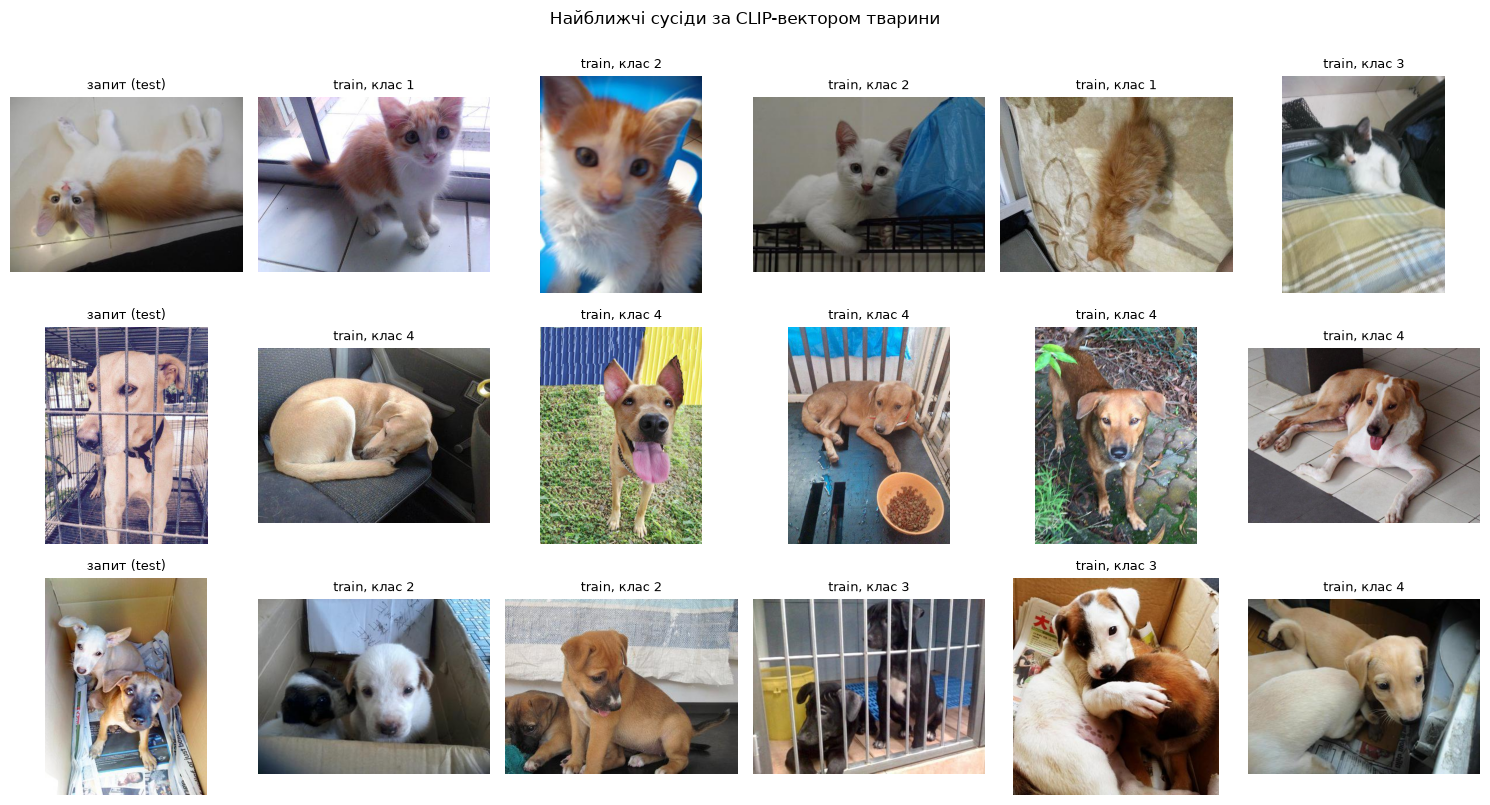

In [8]:
first_photo = photos.drop_duplicates("PetID").set_index("PetID").path
train_idx = np.flatnonzero(pets.split == "train")
rng = np.random.default_rng(SEED)
queries = rng.choice(np.flatnonzero(pets.split == "test"), 3, replace=False)

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for row, q in zip(axes, queries):
    sims = pet_clip[train_idx] @ pet_clip[q]
    top = train_idx[sims.topk(5).indices.numpy()]
    for ax, i in zip(row, [q, *top]):
        ax.imshow(Image.open(first_photo[pets.PetID[i]]))
        ax.axis("off")
        ax.set_title("запит (test)" if i == q else f"train, клас {pets.AdoptionSpeed[i]:.0f}", fontsize=9)
plt.suptitle("Найближчі сусіди за CLIP-вектором тварини", y=1.0)
plt.tight_layout()
plt.savefig(FIG_DIR / "emb_neighbors.png", dpi=120, bbox_inches="tight")
plt.show()